<a href="https://colab.research.google.com/github/fareehanezam/GNCIPL_Projects/blob/main/GNCIPL_Project5_Early_Disease_Outbreak_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Name:

Early Disease Outbreak Detector



# Project Summary
**Project Title:** Early disease Outbreak Detector

**Description:** Predict outbreak based on data patterns

**Key Concepts:** Time-series ANN

**Tools/Frameworks:** Keras

# Git-Hub Link

https://github.com/fareehanezam/GNCIPL_Projects/blob/main/GNCIPL_Project5_Early_Disease_Outbreak_Detector.ipynb

#Problem Statement

The COVID-19 pandemic highlighted the critical need for accurate forecasting of infectious disease outbreaks. Traditional epidemiological models can be complex and require extensive domain knowledge. This project aims to develop a data-driven approach using a time-series Artificial Neural Network (ANN), specifically a Long Short-Term Memory (LSTM) network, to predict the daily new cases of a disease outbreak based on historical patterns in the data. The goal is to provide an early warning system to potentially inform public health responses and resource allocation.

### Setup and Library Imports

**Code Explanation:**
This first code cell imports all the essential Python libraries we'll need for the project.
- `pandas` and `numpy` are for data manipulation and numerical operations.
- `plotly.express` is used for creating interactive charts.
- `sklearn` provides tools for data preprocessing (`MinMaxScaler`) and evaluation (`mean_squared_error`).
- `tensorflow.keras` is the framework we'll use to build our LSTM neural network.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


**Output Explanation:**
The output prints the version of TensorFlow being used, confirming that the library is correctly loaded.

### Load and Reshape the Data

**Code Explanation:**
We start by defining the URL to the raw CSV file in the JHU GitHub repository. The data is in a "wide" format, where each row represents a region and columns represent dates.
1.  We load the data using `pandas.read_csv`.
2.  We drop columns that are not needed for a global forecast (`Province/State`, `Lat`, `Long`).
3.  We use `melt()` to transform the data from a wide format to a "long" format, converting the date columns into a single 'date' column. This is a crucial step for time-series analysis.
4.  Finally, we group by 'date' and sum the cases from all countries to get a single global time series.

In [ ]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
df = pd.read_csv(url)

# Clean and reshape the data
df_cleaned = df.drop(columns=['Province/State', 'Lat', 'Long'])
df_melted = df_cleaned.melt(id_vars=['Country/Region'], var_name='date', value_name='cases')

# Aggregate to a global time series
ts_df = df_melted.groupby('date')['cases'].sum().reset_index()
ts_df['date'] = pd.to_datetime(ts_df['date'], format='%m/%d/%y')
ts_df = ts_df.sort_values('date').set_index('date')

ts_df.head()

,cases
date,
2020-01-22,557
2020-01-23,657
2020-01-24,944
2020-01-25,1437
2020-01-26,2120


**Output Explanation:**
The output display the first 5 rows of the newly created time-series DataFrame, showing two columns: `date` and `cases` (the cumulative global count for that day).

### Daily New Cases Calculation

**Code Explanation:**
The raw data represents *cumulative* cases. For forecasting, it is more effective to predict the change each day, which is the number of *new daily cases*.
1.  We use the `.diff()` method on the 'cases' column. This calculates the difference between each day and the one before it.
2.  The first day will have no prior day to compare to, resulting in a `NaN` (Not a Number) value, which we fill with `0`.
3.  Occasionally, data corrections can lead to negative daily numbers. We use `.clip(lower=0)` to force any negative values to be zero.

In [ ]:
ts_df['daily_cases'] = ts_df['cases'].diff().fillna(0)
ts_df['daily_cases'] = ts_df['daily_cases'].clip(lower=0)

# We only need the daily cases for forecasting
daily_cases_df = ts_df[['daily_cases']]
daily_cases_df.head()

,daily_cases
date,
2020-01-22,0.0
2020-01-23,100.0
2020-01-24,287.0
2020-01-25,493.0
2020-01-26,683.0


**Output Explanation:**
The output shows the DataFrame with a new `daily_cases` column, which will be our target variable for the forecast.

### Exploratory Data Analysis (EDA)

**Code Explanation:**
Now we visualize our prepared data. We use `plotly.express` to create an interactive line chart of global daily new cases. This allows us to see the major waves of the pandemic, observe trends, and understand the data's volatility over time.

In [ ]:
fig = px.line(daily_cases_df, x=daily_cases_df.index, y='daily_cases',
              title='Global Daily New COVID-19 Cases',
              labels={'date': 'Date', 'daily_cases': 'New Cases'})

fig.update_layout(template='plotly_dark')
fig.show()

**Output Explanation:**
An interactive plot, hover over the line to see specific values, and zoom in on different periods to examine the various pandemic waves more closely.

### Data Scaling and Sequence Creation

**Code Explanation:**
Neural networks perform better when input data is on a small, standardized scale.
1.  **Scaling:** We use `MinMaxScaler` to transform the `daily_cases` values to a range between 0 and 1.
2.  **Sequence Creation:** We define a function to convert the linear time series into supervised learning sequences. For a `SEQUENCE_LENGTH` of 60, this function takes 60 days of data as the input (`X`) and the 61st day's data as the target label (`y`).
3.  **Train-Test Split:** We split our data into training and testing sets. For time-series data, this split must be chronological to ensure we are training on the past and testing on the future.

In [ ]:
# 1. Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(daily_cases_df['daily_cases'].values.reshape(-1, 1))

# 2. Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length), 0])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 60 # Use 60 days of data to predict the next day
X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 3. Chronological train-test split (80% train, 20% test)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (866, 60, 1)
Training labels shape: (866,)
Test data shape: (217, 60, 1)
Test labels shape: (217,)


**Output Explanation:**
The output prints the shapes of the final `X_train`, `X_test`, `y_train`, and `y_test` arrays, confirming that our data is correctly structured for the LSTM model.

### Building the LSTM Model

**Code Explanation:**
We define our neural network architecture using Keras's `Sequential` API.
- `LSTM(units=50, ...)`: The first layer is an LSTM layer with 50 neurons. It's the core of our model, designed to learn patterns from the input sequences. `return_sequences=True` means it passes its full sequence output to the next layer.
- `Dropout(0.2)`: This is a regularization technique that randomly sets 20% of neuron activations to zero during training to prevent overfitting.
- `LSTM(units=50)`: A second LSTM layer to learn more complex patterns.
- `Dense(units=1)`: The final output layer is a standard Dense layer with one neuron, which will output a single predicted value.
- `model.compile(...)`: We configure the model for training by specifying the `adam` optimizer and `mean_squared_error` as the loss function.



In [ ]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

**Output Explanation:**
The `model.summary()` command prints a table summarizing the model's architecture, including each layer's type, output shape, and number of trainable parameters.

### Model Training

**Code Explanation:**
We train the model using the `model.fit()` function.
- We pass the training data (`X_train`, `y_train`).
- `epochs=20` means the model will see the entire training dataset 20 times.
- `batch_size=32` means the model updates its internal weights after processing 32 sequences at a time.
- `validation_split=0.1` sets aside the last 10% of the training data to evaluate the model's performance on data it isn't directly training on, which helps monitor for overfitting.



Training the LSTM model...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0168 - val_loss: 0.0056
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0067 - val_loss: 0.0046
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0042 - val_loss: 0.0052
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0039 - val_loss: 0.0051
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0031 - val_loss: 0.0047
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0026 - val_loss: 0.0047
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0032 - val_loss: 0.0047
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0034 - val_loss: 0.0049
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0033 - val_loss: 0.0049
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0031 - val_loss: 0.0049
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0033 - val_loss: 0.0048
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━

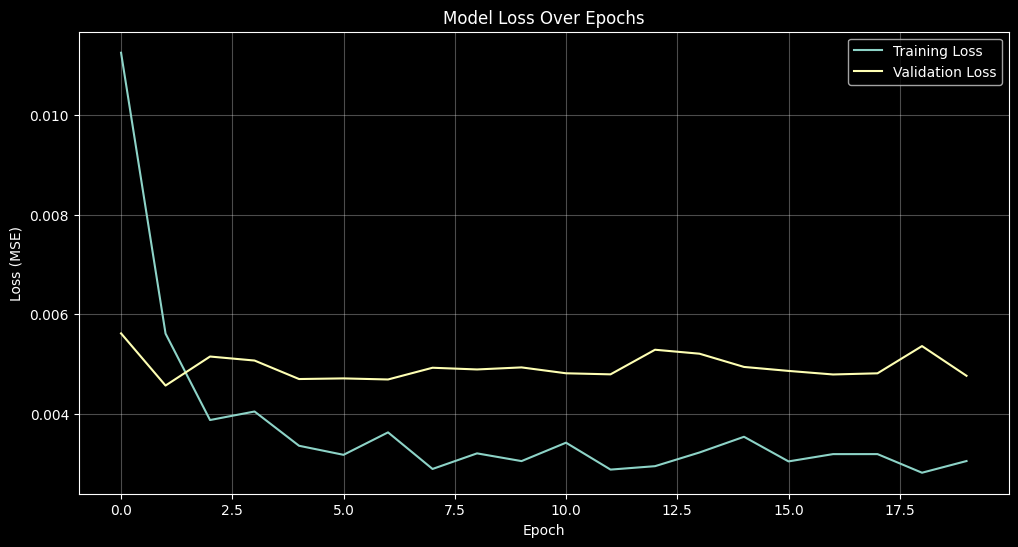

In [ ]:
print("Training the LSTM model...")
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
print("\nTraining complete!")

# Plot training & validation loss
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Output Explanation:**
The output shows the training progress for each epoch, displaying the `loss` on the training data and the `val_loss` on the validation data. We expect to see both values decrease over time. A plot is to visualize the training and validation loss curves.

### Evaluation and Visualization of Predictions

**Code Explanation:**
This is the final step where we assess our model's performance on the unseen test data.
1.  `model.predict(X_test)` generates predictions for the test set. These predictions are still on the scaled (0-1) range.
2.  `scaler.inverse_transform()` converts both our predictions and the actual test labels back to the original scale of daily case counts.
3.  We calculate the **Root Mean Squared Error (RMSE)**, which gives us a single number representing the average error of our model in terms of daily cases.
4.  Finally, we plot the actual test values against our model's predictions to visually inspect how well it performed.



In [ ]:
# Make predictions
predictions_scaled = model.predict(X_test)

# Inverse scale the predictions and actuals
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse:,.0f} cases")

# Create a DataFrame for plotting
test_data_index = daily_cases_df.index[split_index + SEQUENCE_LENGTH:]
results_df = pd.DataFrame({'Actual Cases': y_test_actual.flatten(), 'Predicted Cases': predictions.flatten()}, index=test_data_index)

# Plot the results
fig = px.line(results_df, x=results_df.index, y=['Actual Cases', 'Predicted Cases'],
              title='COVID-19 Daily Cases: Actual vs. Predicted',
              labels={'value': 'Number of Cases', 'date': 'Date'})
fig.update_layout(template='plotly_dark', legend_title_text='Legend')
fig.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
Root Mean Squared Error (RMSE) on Test Data: 161,023 cases


**Output Explanation:**
The output prints the calculated RMSE. It displays a graph showing the true number of daily cases from the test set in one color, and the model's predicted values in another. This allows for a direct visual comparison of the forecast's accuracy.